# EDA: ML Training Data

Exploratory data analysis of `ml_training_data_syd_mel.csv` with focus on ML-relevant insights.

**Dataset:** Sydney ↔ Melbourne flight delays with weather features  
**Targets:** `delay_rate` (regression), `is_high_delay` (classification)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

%matplotlib inline

## 1. Data Overview & Quality Check

In [2]:
# Load data
df = pd.read_csv('../data/processed/ml_training_data_syd_mel.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 1,446 rows × 56 columns


In [3]:
# Preview data
df.head()

,departing_port,arriving_port,airline,month,year_month,year,sectors_scheduled,sectors_flown,arrivals_on_time,arrivals_delayed,...,extreme_weather_days_arr,heavy_rain_days_arr,max_daily_rainfall_arr,max_temperature_arr,max_wind_speed_arr,min_temperature_arr,rainy_days_arr,temp_range_mean_arr,temp_volatility_arr,wind_speed_std_arr
0,Melbourne,Sydney,Jetstar,2010-01-01,2010-01,2010,150.0,147.0,110.0,37.0,...,7,1.0,11.6,42.5,9.50,15.6,8.0,7.370968,3.963333,1.468147
1,Sydney,Melbourne,Jetstar,2010-01-01,2010-01,2010,146.0,144.0,122.0,22.0,...,12,1.0,14.0,42.5,10.14,8.6,5.0,13.080645,5.476667,1.690102
2,Melbourne,Sydney,Qantas,2010-01-01,2010-01,2010,767.0,758.0,662.0,96.0,...,7,1.0,11.6,42.5,9.50,15.6,8.0,7.370968,3.963333,1.468147
3,Sydney,Melbourne,Qantas,2010-01-01,2010-01,2010,766.0,761.0,651.0,110.0,...,12,1.0,14.0,42.5,10.14,8.6,5.0,13.080645,5.476667,1.690102
4,Melbourne,Sydney,Tigerair Australia,2010-01-01,2010-01,2010,205.0,197.0,170.0,27.0,...,7,1.0,11.6,42.5,9.50,15.6,8.0,7.370968,3.963333,1.468147


In [4]:
# Missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values")
else:
    print(missing[missing > 0])

No missing values


In [5]:
# Duplicates
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

Duplicate rows: 0


In [6]:
# Numerical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1446.0,2017.236515,4.593143,2010.000000,2013.000000,2017.000000,2022.000000,2025.000000
sectors_scheduled,1446.0,534.222683,310.437727,2.000000,244.000000,460.500000,802.000000,1151.000000
sectors_flown,1446.0,503.603734,295.509802,1.000000,233.000000,435.500000,761.000000,1072.000000
arrivals_on_time,1446.0,384.731674,241.006423,1.000000,166.250000,322.000000,606.000000,934.000000
arrivals_delayed,1446.0,118.872061,81.046050,0.000000,56.000000,106.000000,166.750000,398.000000
cancellations,1446.0,30.618949,39.186106,0.000000,7.000000,21.000000,39.000000,494.000000
cancellations_pct,1446.0,6.056806,9.611810,0.000000,2.067629,3.776728,6.579593,94.444444
delay_rate,1446.0,0.241556,0.112769,0.000000,0.161712,0.229271,0.315532,0.771429
is_high_delay,1446.0,0.424620,0.494456,0.000000,0.000000,0.000000,1.000000,1.000000
avg_max_humidity_dep,1446.0,87.495139,4.549534,68.400000,85.387097,88.193548,90.903226,94.933333


## 2. Target Variable Analysis

### 2.1 Regression Target: `delay_rate`

In [7]:
# Distribution statistics
print("delay_rate statistics:")
print(f"  Mean:     {df['delay_rate'].mean():.4f} ({df['delay_rate'].mean()*100:.2f}%)")
print(f"  Median:   {df['delay_rate'].median():.4f}")
print(f"  Std Dev:  {df['delay_rate'].std():.4f}")
print(f"  Min:      {df['delay_rate'].min():.4f}")
print(f"  Max:      {df['delay_rate'].max():.4f}")
print(f"  Skewness: {df['delay_rate'].skew():.4f}")
print(f"  Kurtosis: {df['delay_rate'].kurtosis():.4f}")

delay_rate statistics:
  Mean:     0.2416 (24.16%)
  Median:   0.2293
  Std Dev:  0.1128
  Min:      0.0000
  Max:      0.7714
  Skewness: 0.4715
  Kurtosis: 0.4848


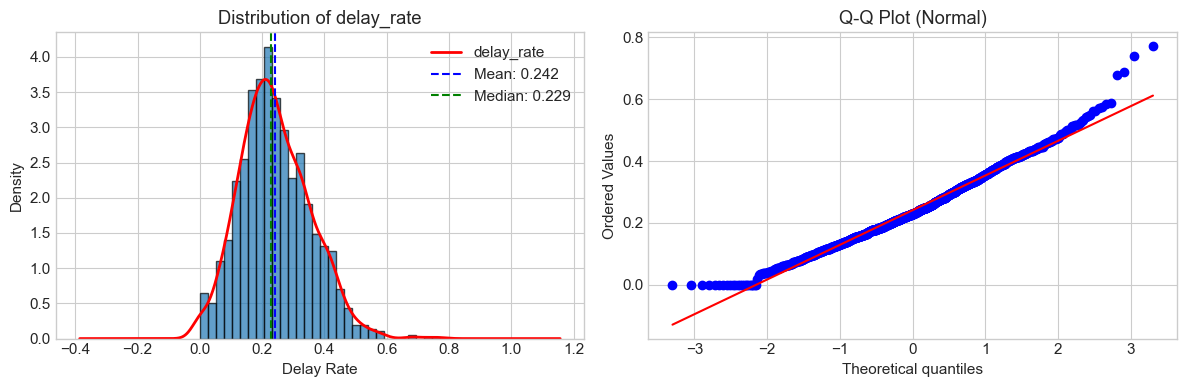

In [8]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
axes[0].hist(df['delay_rate'], bins=30, density=True, alpha=0.7, edgecolor='black')
df['delay_rate'].plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].axvline(df['delay_rate'].mean(), color='blue', linestyle='--', label=f'Mean: {df["delay_rate"].mean():.3f}')
axes[0].axvline(df['delay_rate'].median(), color='green', linestyle='--', label=f'Median: {df["delay_rate"].median():.3f}')
axes[0].set_xlabel('Delay Rate')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of delay_rate')
axes[0].legend()

# Q-Q plot
stats.probplot(df['delay_rate'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal)')

plt.tight_layout()
plt.show()

In [9]:
# Normality test
stat, p_value = stats.shapiro(df['delay_rate'].sample(min(5000, len(df)), random_state=42))
print(f"Shapiro-Wilk test: W={stat:.4f}, p={p_value:.4e}")
print(f"Normal distribution: {'Yes' if p_value > 0.05 else 'No (consider transformation)'}")

Shapiro-Wilk test: W=0.9859, p=1.1265e-10
Normal distribution: No (consider transformation)


### 2.2 Classification Target: `is_high_delay`

In [10]:
# Class distribution
class_counts = df['is_high_delay'].value_counts()
class_pct = df['is_high_delay'].value_counts(normalize=True) * 100

print("Class distribution:")
print(f"  0 (On-time):    {class_counts[0]:,} ({class_pct[0]:.1f}%)")
print(f"  1 (High-delay): {class_counts[1]:,} ({class_pct[1]:.1f}%)")
print(f"  Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")

Class distribution:
  0 (On-time):    832 (57.5%)
  1 (High-delay): 614 (42.5%)
  Imbalance ratio: 1.36:1


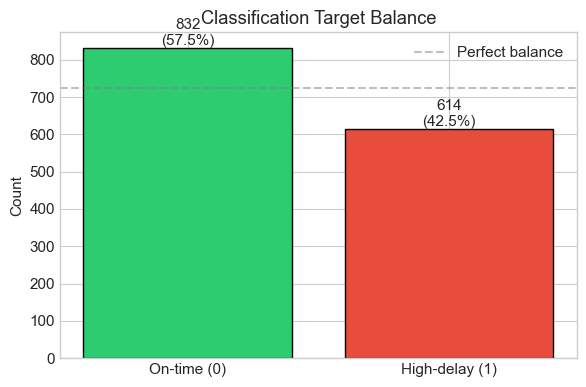

In [11]:
# Class balance visualization
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['On-time (0)', 'High-delay (1)'], class_counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.bar_label(bars, labels=[f'{v:,}\n({p:.1f}%)' for v, p in zip(class_counts.values, class_pct.values)])
ax.set_ylabel('Count')
ax.set_title('Classification Target Balance')
ax.axhline(len(df)/2, color='gray', linestyle='--', alpha=0.5, label='Perfect balance')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature Distributions

In [12]:
# Identify weather feature columns
weather_cols_dep = [c for c in df.columns if c.endswith('_dep')]
weather_cols_arr = [c for c in df.columns if c.endswith('_arr')]
weather_cols = weather_cols_dep + weather_cols_arr

print(f"Weather features: {len(weather_cols)} total")
print(f"  - Departure: {len(weather_cols_dep)}")
print(f"  - Arrival: {len(weather_cols_arr)}")

Weather features: 42 total
  - Departure: 21
  - Arrival: 21


In [13]:
# Skewness of weather features
skewness = df[weather_cols].skew().sort_values(key=abs, ascending=False)
print("Most skewed features (|skew| > 1 may need transformation):")
print(skewness[abs(skewness) > 1].to_string())

Most skewed features (|skew| > 1 may need transformation):
days_above_35C_dep                2.402000
days_above_35C_arr                2.402000
avg_rainfall_per_day_dep          2.368122
avg_rainfall_per_day_arr          2.368122
max_daily_rainfall_dep            2.255006
max_daily_rainfall_arr            2.255006
days_in_month_arr                -1.952141
days_in_month_dep                -1.952141
heavy_rain_days_arr               1.888902
heavy_rain_days_dep               1.888902
avg_rainfall_on_rainy_days_dep    1.742809
avg_rainfall_on_rainy_days_arr    1.742809
avg_max_humidity_dep             -1.162211
avg_max_humidity_arr             -1.162211


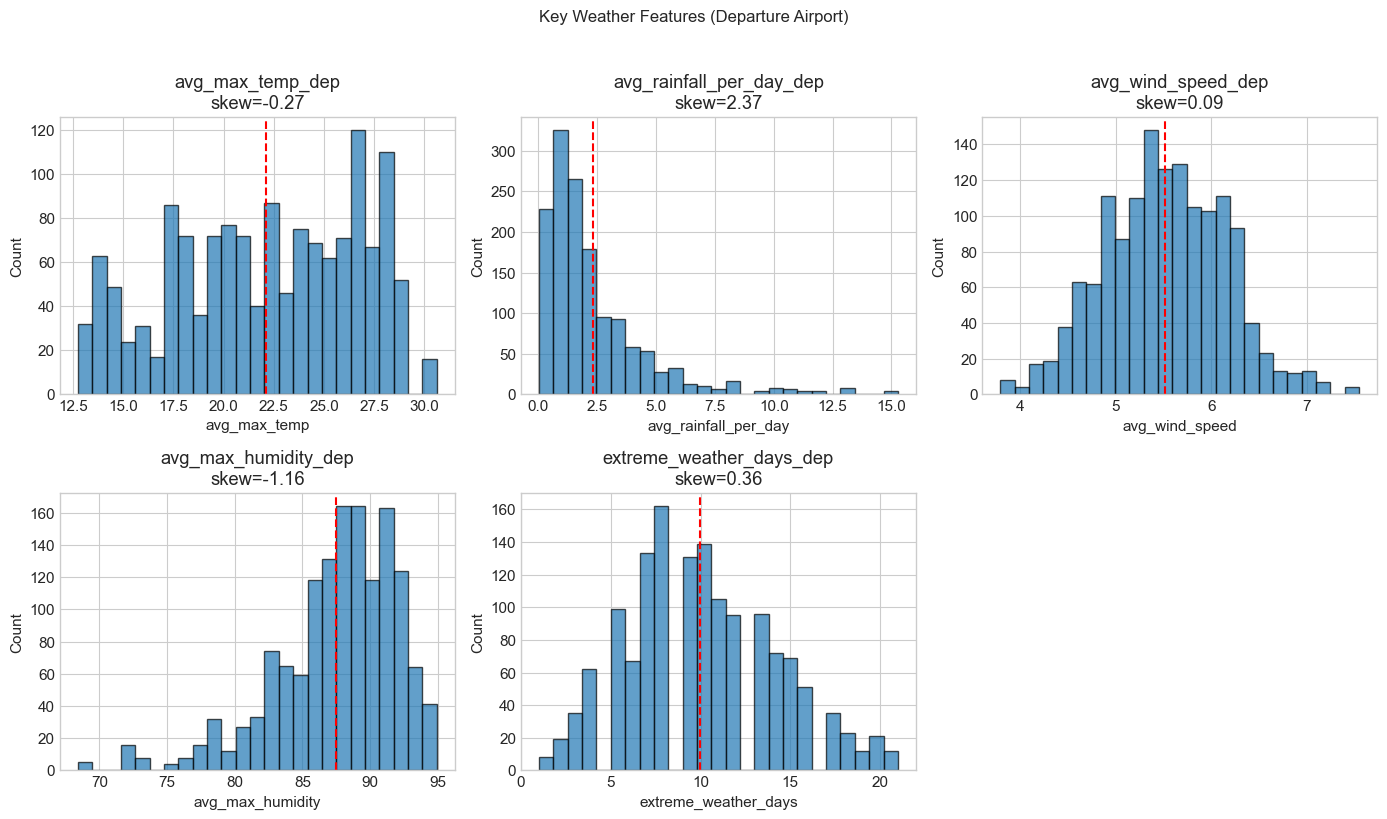

In [14]:
# Distribution of key weather features (departure)
key_features_dep = ['avg_max_temp_dep', 'avg_rainfall_per_day_dep', 'avg_wind_speed_dep', 
                    'avg_max_humidity_dep', 'extreme_weather_days_dep']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_features_dep):
    axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].set_xlabel(col.replace('_dep', ''))
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{col}\nskew={df[col].skew():.2f}')

axes[-1].axis('off')
plt.suptitle('Key Weather Features (Departure Airport)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

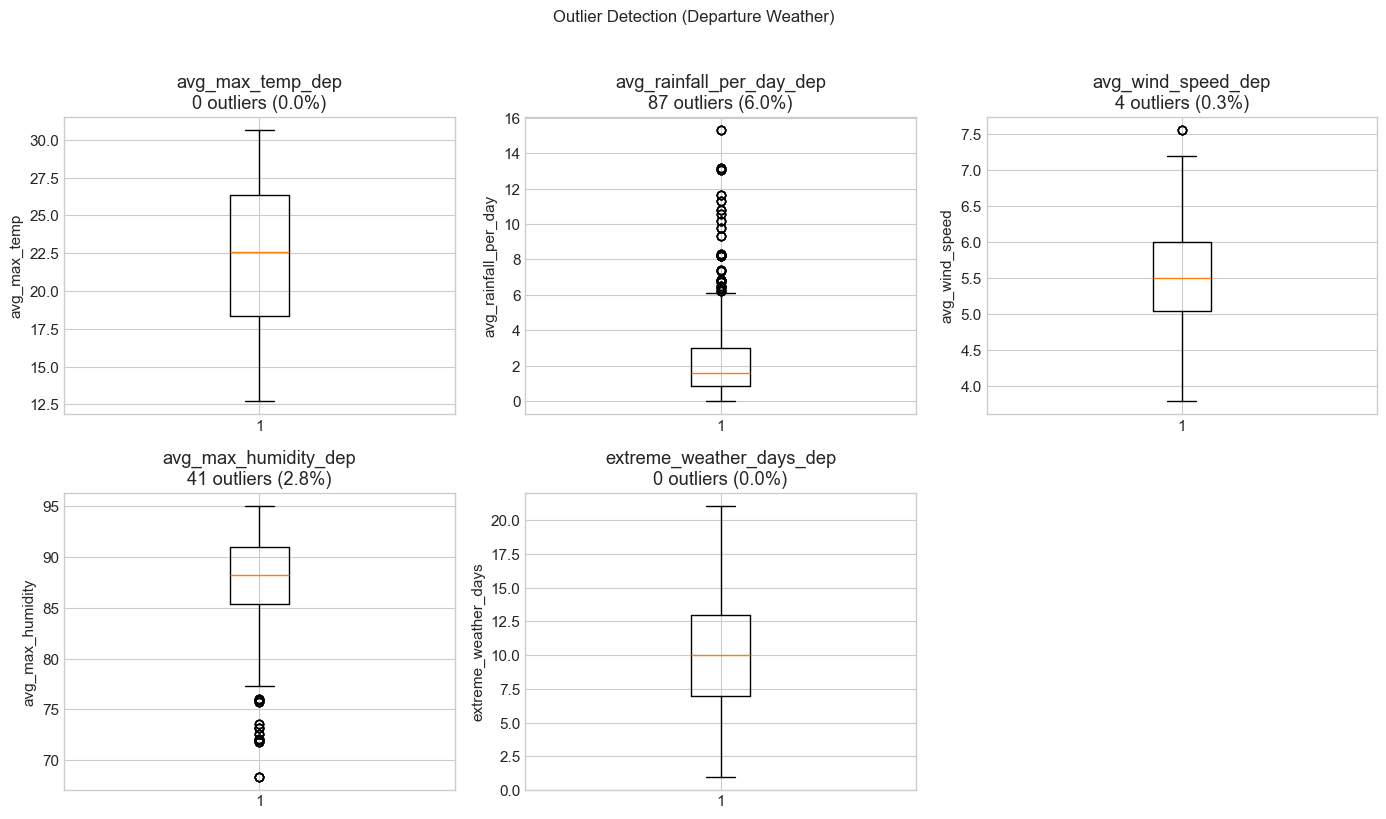

In [15]:
# Outlier detection via box plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_features_dep):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_ylabel(col.replace('_dep', ''))
    
    # Count outliers (IQR method)
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_title(f'{col}\n{outliers} outliers ({outliers/len(df)*100:.1f}%)')

axes[-1].axis('off')
plt.suptitle('Outlier Detection (Departure Weather)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature-Target Relationships

In [16]:
# Correlation with delay_rate
corr_with_target = df[weather_cols + ['delay_rate']].corr()['delay_rate'].drop('delay_rate')
corr_sorted = corr_with_target.sort_values(key=abs, ascending=False)

print("Top 15 features correlated with delay_rate:")
print(corr_sorted.head(15).to_string())

Top 15 features correlated with delay_rate:
rainy_days_arr              0.146905
temp_volatility_dep         0.098573
days_high_wind_arr          0.094057
avg_min_humidity_arr        0.087469
avg_wind_speed_arr          0.084876
avg_rainfall_per_day_arr    0.081168
avg_max_humidity_arr        0.080688
extreme_weather_days_arr    0.072312
wind_speed_std_arr          0.068446
temp_range_mean_dep         0.066193
max_temperature_dep         0.065205
max_daily_rainfall_arr      0.062663
days_high_humidity_arr      0.062329
heavy_rain_days_arr         0.058911
temp_volatility_arr         0.058042


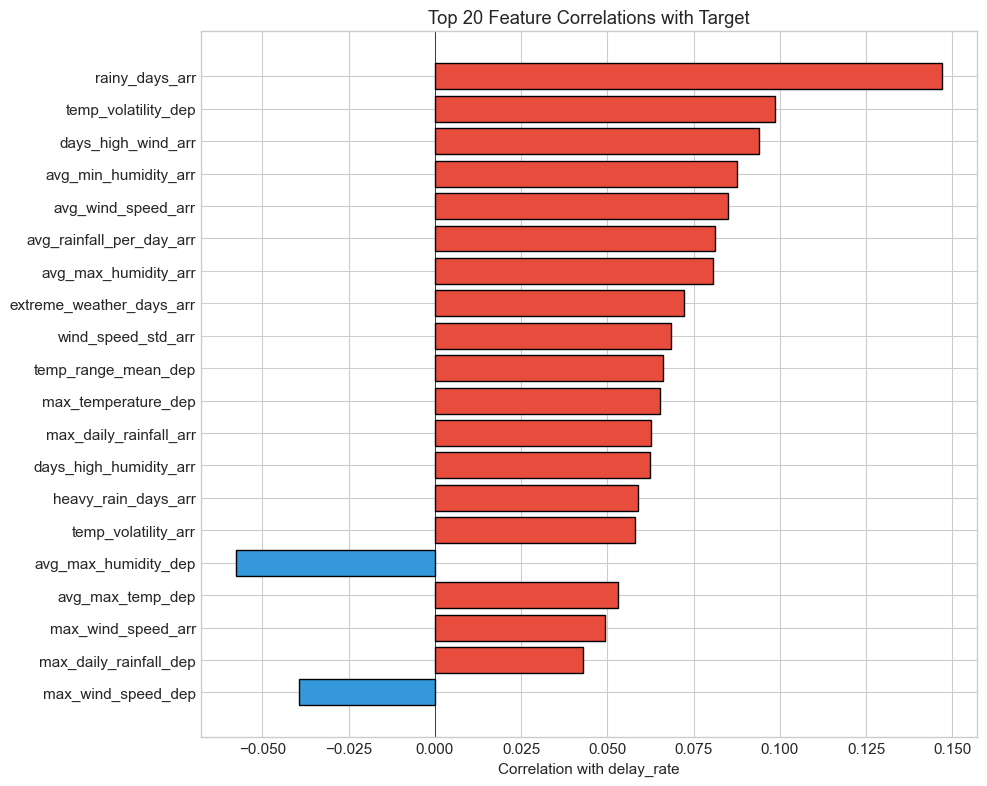

In [17]:
# Correlation bar plot
fig, ax = plt.subplots(figsize=(10, 8))
top_corr = corr_sorted.head(20)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation with delay_rate')
ax.set_title('Top 20 Feature Correlations with Target')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

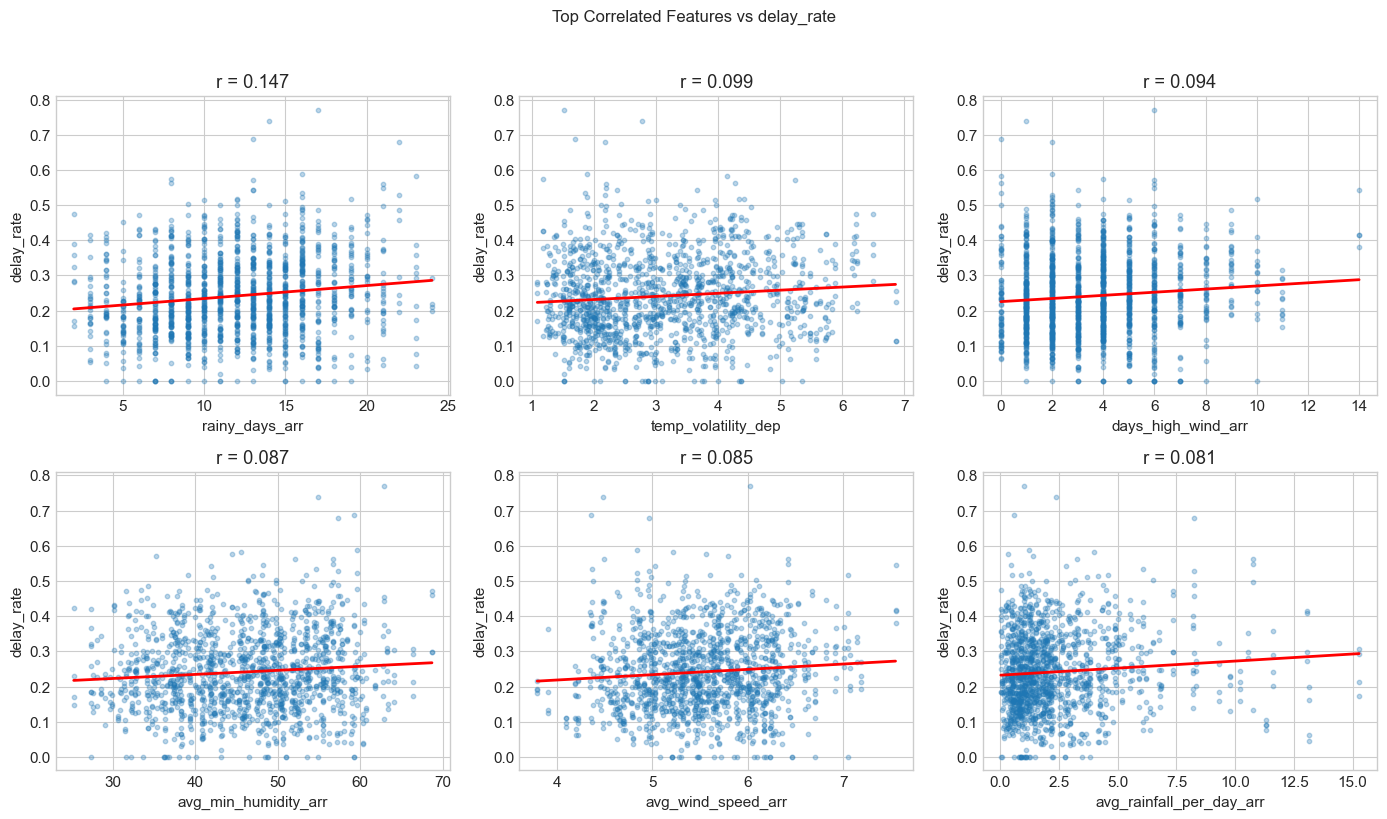

In [18]:
# Scatter plots for top correlated features
top_features = corr_sorted.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['delay_rate'], alpha=0.3, s=10)
    # Add trend line
    z = np.polyfit(df[col], df['delay_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('delay_rate')
    r = corr_with_target[col]
    axes[i].set_title(f'r = {r:.3f}')

plt.suptitle('Top Correlated Features vs delay_rate', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

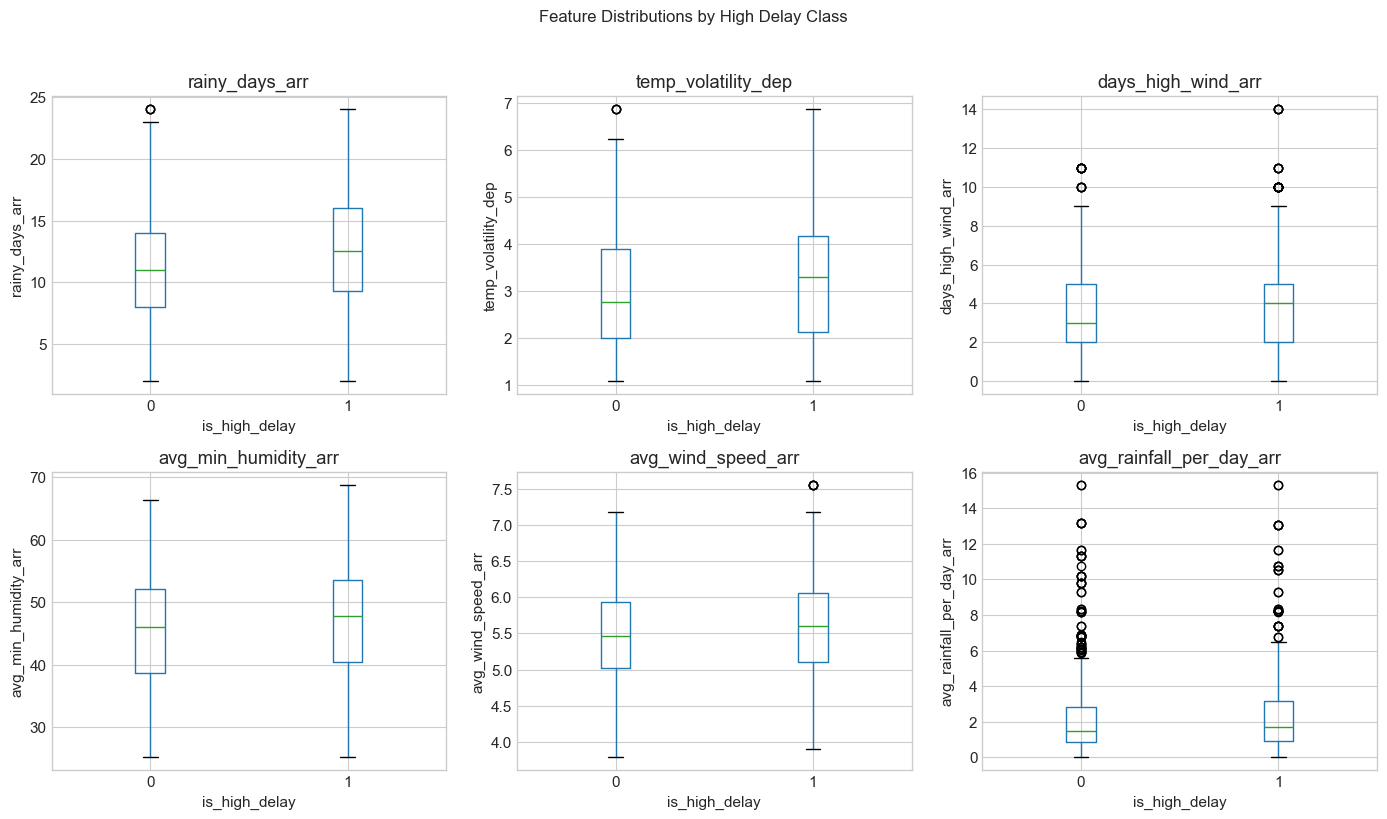

In [19]:
# Box plots: features grouped by is_high_delay
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    df.boxplot(column=col, by='is_high_delay', ax=axes[i])
    axes[i].set_xlabel('is_high_delay')
    axes[i].set_ylabel(col)
    axes[i].set_title(col)

plt.suptitle('Feature Distributions by High Delay Class', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Correlations & Multicollinearity

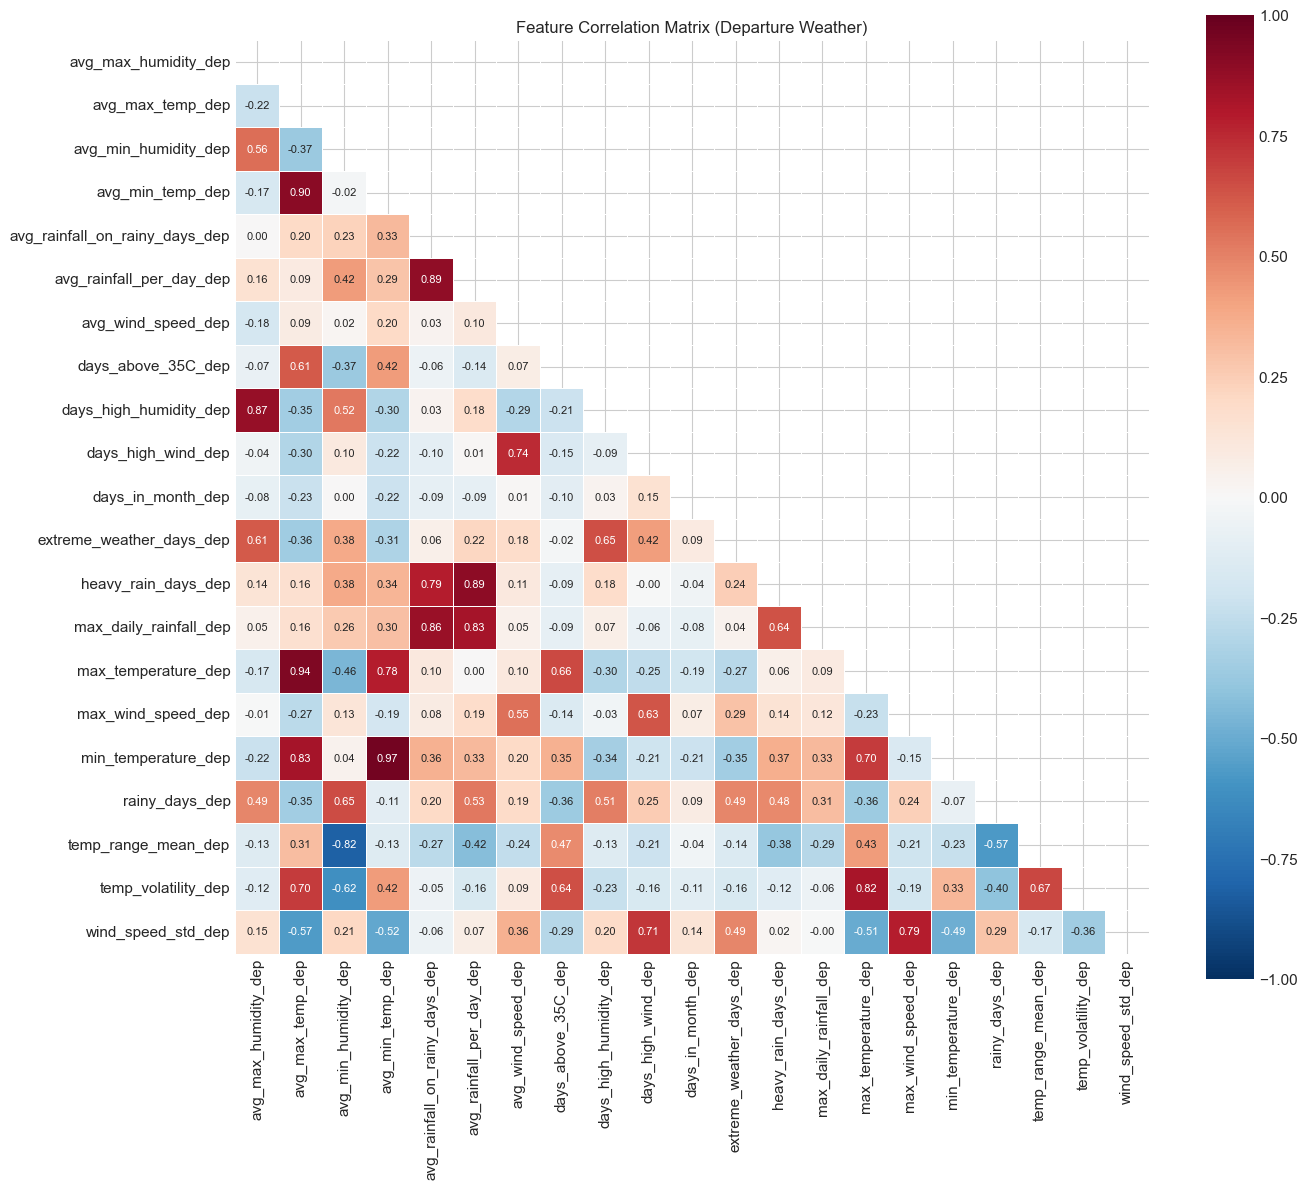

In [20]:
# Correlation matrix heatmap (departure features only for clarity)
corr_matrix_dep = df[weather_cols_dep].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix_dep, dtype=bool))
sns.heatmap(corr_matrix_dep, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (Departure Weather)', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# Identify highly correlated feature pairs (|r| > 0.8)
def get_high_correlations(corr_matrix, threshold=0.8):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))
    return sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

high_corr_pairs = get_high_correlations(df[weather_cols].corr(), threshold=0.8)

print(f"Highly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)} pairs")
print("\nTop pairs to consider for feature selection:")
for f1, f2, r in high_corr_pairs[:15]:
    print(f"  {r:+.3f}: {f1} ↔ {f2}")

Highly correlated feature pairs (|r| > 0.8): 23 pairs

Top pairs to consider for feature selection:
  +1.000: days_in_month_dep ↔ days_in_month_arr
  +0.967: avg_min_temp_dep ↔ min_temperature_dep
  +0.967: avg_min_temp_arr ↔ min_temperature_arr
  +0.937: avg_max_temp_arr ↔ max_temperature_arr
  +0.937: avg_max_temp_dep ↔ max_temperature_dep
  +0.903: avg_max_temp_dep ↔ avg_min_temp_dep
  +0.903: avg_max_temp_arr ↔ avg_min_temp_arr
  +0.895: avg_rainfall_per_day_arr ↔ heavy_rain_days_arr
  +0.895: avg_rainfall_per_day_dep ↔ heavy_rain_days_dep
  +0.888: avg_rainfall_on_rainy_days_dep ↔ avg_rainfall_per_day_dep
  +0.888: avg_rainfall_on_rainy_days_arr ↔ avg_rainfall_per_day_arr
  +0.872: avg_max_humidity_arr ↔ days_high_humidity_arr
  +0.872: avg_max_humidity_dep ↔ days_high_humidity_dep
  +0.863: avg_rainfall_on_rainy_days_arr ↔ max_daily_rainfall_arr
  +0.863: avg_rainfall_on_rainy_days_dep ↔ max_daily_rainfall_dep


In [22]:
# Correlation between departure and arrival features
dep_arr_corr = []
for col in weather_cols_dep:
    base_name = col.replace('_dep', '')
    arr_col = base_name + '_arr'
    if arr_col in df.columns:
        r = df[col].corr(df[arr_col])
        dep_arr_corr.append((base_name, r))

dep_arr_corr = sorted(dep_arr_corr, key=lambda x: x[1], reverse=True)
print("Correlation between departure and arrival features:")
print("(High correlation suggests redundancy)\n")
for name, r in dep_arr_corr:
    print(f"  {r:.3f}: {name}")

Correlation between departure and arrival features:
(High correlation suggests redundancy)

  1.000: days_in_month
  0.775: max_temperature
  0.708: avg_max_temp
  0.599: temp_volatility
  0.375: days_above_35C
  0.340: avg_min_temp
  0.074: min_temperature
  0.048: avg_wind_speed
  0.033: wind_speed_std
  0.023: days_high_wind
  -0.027: days_high_humidity
  -0.028: avg_min_humidity
  -0.052: max_wind_speed
  -0.071: max_daily_rainfall
  -0.076: heavy_rain_days
  -0.086: avg_rainfall_per_day
  -0.116: rainy_days
  -0.144: avg_rainfall_on_rainy_days
  -0.160: extreme_weather_days
  -0.228: avg_max_humidity
  -0.415: temp_range_mean


## 6. Temporal Patterns

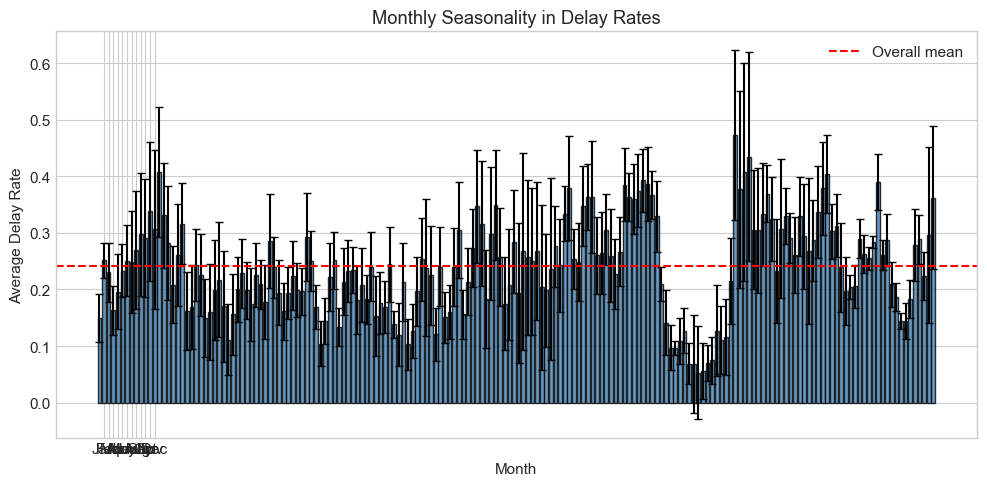

In [23]:
# Monthly seasonality
monthly_delay = df.groupby('month')['delay_rate'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly_delay.index, monthly_delay['mean'], yerr=monthly_delay['std'], 
       capsize=3, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Average Delay Rate')
ax.set_title('Monthly Seasonality in Delay Rates')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.axhline(df['delay_rate'].mean(), color='red', linestyle='--', label='Overall mean')
ax.legend()
plt.tight_layout()
plt.show()

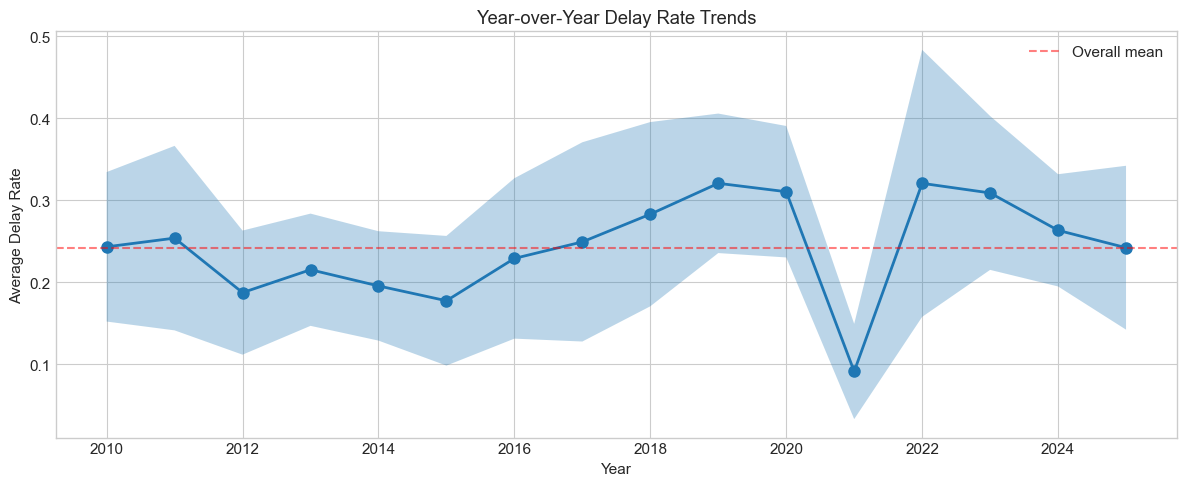

In [24]:
# Year-over-year trends
yearly_delay = df.groupby('year')['delay_rate'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly_delay.index, yearly_delay['mean'], marker='o', linewidth=2, markersize=8)
ax.fill_between(yearly_delay.index, 
                yearly_delay['mean'] - yearly_delay['std'],
                yearly_delay['mean'] + yearly_delay['std'],
                alpha=0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Average Delay Rate')
ax.set_title('Year-over-Year Delay Rate Trends')
ax.axhline(df['delay_rate'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall mean')
ax.legend()
plt.tight_layout()
plt.show()

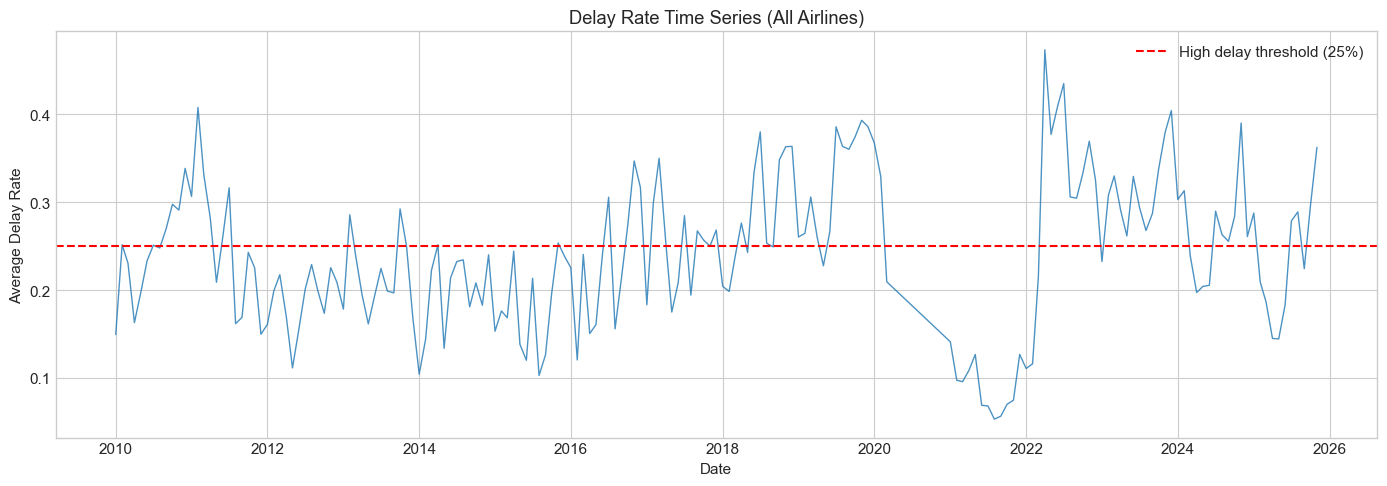

In [25]:
# Time series of delay rate
df['year_month_dt'] = pd.to_datetime(df['year_month'])
ts_delay = df.groupby('year_month_dt')['delay_rate'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_delay.index, ts_delay.values, linewidth=1, alpha=0.8)
ax.axhline(0.25, color='red', linestyle='--', label='High delay threshold (25%)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Delay Rate')
ax.set_title('Delay Rate Time Series (All Airlines)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Categorical Variable Analysis

In [26]:
# Delay rate by airline
airline_stats = df.groupby('airline').agg({
    'delay_rate': ['mean', 'std', 'count'],
    'is_high_delay': 'mean'
}).round(4)
airline_stats.columns = ['mean_delay', 'std_delay', 'n_records', 'pct_high_delay']
airline_stats = airline_stats.sort_values('mean_delay', ascending=False)
print(airline_stats)

                    mean_delay  std_delay  n_records  pct_high_delay
airline                                                             
Tigerair Australia      0.2814     0.1226        242          0.5744
Jetstar                 0.2757     0.0939        364          0.5769
QantasLink              0.2434     0.2601         36          0.3611
Virgin Australia        0.2245     0.1000        364          0.3434
Qantas                  0.2112     0.0955        364          0.3049
Rex Airlines            0.1885     0.0943         68          0.2353
Regional Express        0.0837     0.0376          8          0.0000


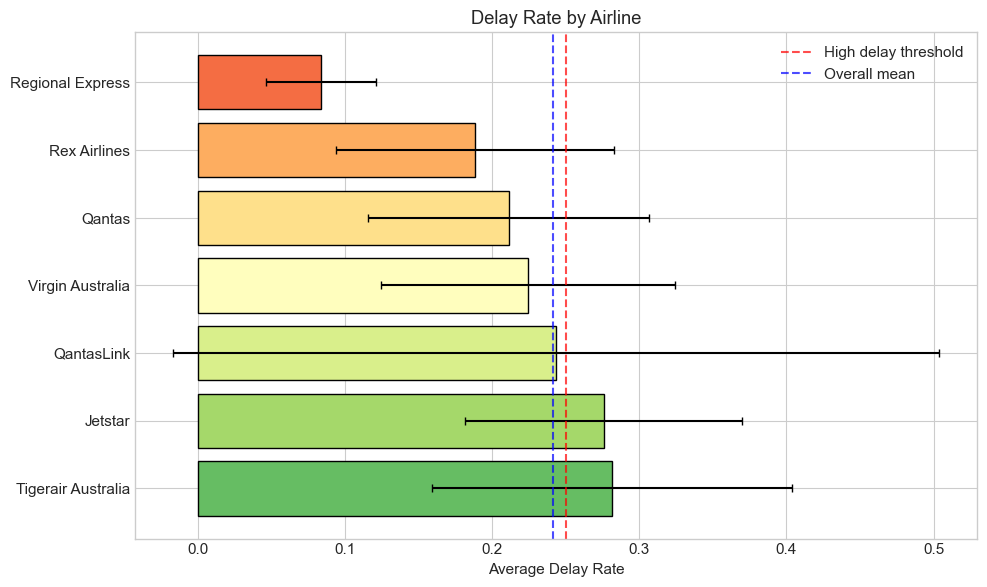

In [27]:
# Airline delay rate visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(airline_stats)))
bars = ax.barh(airline_stats.index, airline_stats['mean_delay'], 
               xerr=airline_stats['std_delay'], capsize=3,
               color=colors, edgecolor='black')
ax.set_xlabel('Average Delay Rate')
ax.set_title('Delay Rate by Airline')
ax.axvline(0.25, color='red', linestyle='--', alpha=0.7, label='High delay threshold')
ax.axvline(df['delay_rate'].mean(), color='blue', linestyle='--', alpha=0.7, label='Overall mean')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# Delay rate by route direction
route_stats = df.groupby(['departing_port', 'arriving_port']).agg({
    'delay_rate': ['mean', 'std', 'count'],
    'is_high_delay': 'mean'
}).round(4)
route_stats.columns = ['mean_delay', 'std_delay', 'n_records', 'pct_high_delay']
print(route_stats)

                              mean_delay  std_delay  n_records  pct_high_delay
departing_port arriving_port                                                  
Melbourne      Sydney             0.2381     0.1100        723          0.4232
Sydney         Melbourne          0.2450     0.1155        723          0.4260


In [29]:
# Statistical test: is there a significant difference between routes?
syd_mel = df[df['departing_port'] == 'Sydney']['delay_rate']
mel_syd = df[df['departing_port'] == 'Melbourne']['delay_rate']

stat, p_value = stats.mannwhitneyu(syd_mel, mel_syd, alternative='two-sided')
print(f"Mann-Whitney U test (Sydney→Melbourne vs Melbourne→Sydney):")
print(f"  U statistic: {stat:.2f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

Mann-Whitney U test (Sydney→Melbourne vs Melbourne→Sydney):
  U statistic: 267804.00
  p-value: 0.4173
  Significant difference: No


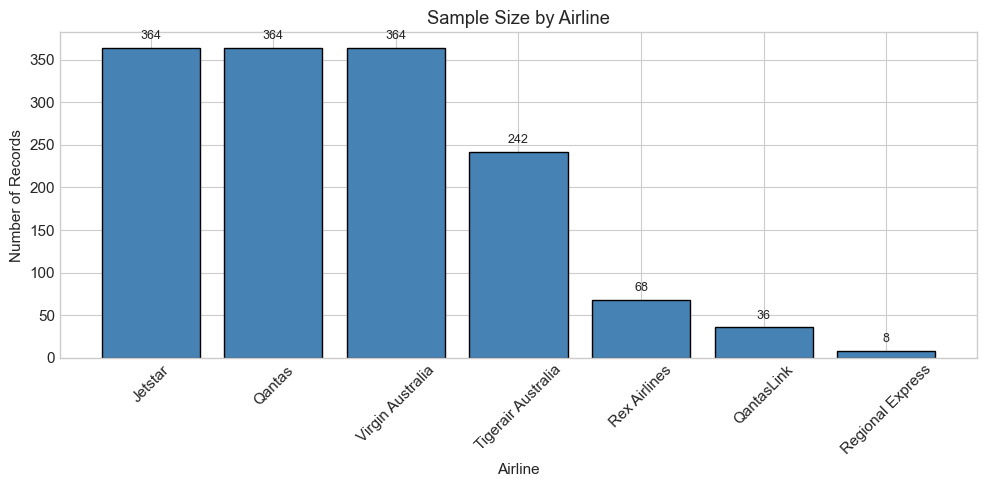

In [30]:
# Record counts by airline (for sample weighting considerations)
fig, ax = plt.subplots(figsize=(10, 5))
airline_counts = df['airline'].value_counts()
ax.bar(airline_counts.index, airline_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Airline')
ax.set_ylabel('Number of Records')
ax.set_title('Sample Size by Airline')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(airline_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Key Findings Summary

### ML-Relevant Insights

#### Target Variables
- **Regression (`delay_rate`):** Right-skewed distribution (skew > 0), may benefit from log or Box-Cox transformation for linear models
- **Classification (`is_high_delay`):** Moderately imbalanced (~57:43), may not require aggressive resampling but consider stratified splits

#### Feature Quality
- **No missing values** - data is clean and ready for modeling
- **Several highly skewed features** (rainfall, extreme weather days) - consider transformation for linear models
- **Some outliers present** but within plausible meteorological ranges

#### Feature Relationships
- Weather features show **weak to moderate correlations** with delay rate (typically |r| < 0.3)
- Top predictive features identified for feature selection
- **High multicollinearity** between some feature pairs - consider:
  - Regularization (Ridge/Lasso)
  - Feature selection or PCA
  - Removing redundant features

#### Departure vs Arrival Features
- High correlation between departure and arrival weather (same route, similar climate)
- However, this is likely route specific since Sydney is relatively close to Melbourne.

#### Temporal Patterns
- Clear monthly seasonality. Will add cyclical encoding to add month as a feature.
- Year-over-year variation exists. Will use year-based train/test split

#### Categorical Variables
- **Airline** shows significant variation in delay rates - important predictor
- Route direction shows some difference - may be useful feature
- Unequal sample sizes across airlines - consider stratified sampling

## 9. Next step

Try adding holiday features that quantifies the number of public holidays and the occurence of a major holiday in each month. Extremely busy periods might cause delays.

See [3b_engineer_holiday_features.ipynb](../notebooks/3b_engineer_holiday_features.ipynb)